# Profiling do Data Warehouse

Caracterização descritiva do DW dimensional antes de qualquer formulação de hipótese: volumetria,
distribuições, concentração geográfica e composição do pedido. Serve de base para as cinco perguntas
de negócio, que estão em [`analise_requerida_case.ipynb`](analise_requerida_case.ipynb).


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

db_path = '../data/processed/olist.duckdb'
if not os.path.exists(db_path):
    db_path = 'data/processed/olist.duckdb'

conn = duckdb.connect(db_path, read_only=True)
print("Conexao com o DuckDB estabelecida.")


Conexao com o DuckDB estabelecida.


## 1. Volumetria e integridade do modelo

Contagem por entidade e verificação das duas propriedades que a modelagem promete: grão de um pedido
por linha na `fato_pedidos` e ausência de registros órfãos entre as fatos.


In [2]:
query_volumetria = """
SELECT 'dim_cliente' AS tabela, COUNT(*) AS registros FROM dim_cliente
UNION ALL SELECT 'dim_vendedor', COUNT(*) FROM dim_vendedor
UNION ALL SELECT 'dim_produto',  COUNT(*) FROM dim_produto
UNION ALL SELECT 'dim_tempo',    COUNT(*) FROM dim_tempo
UNION ALL SELECT 'fato_pedidos', COUNT(*) FROM fato_pedidos
UNION ALL SELECT 'fato_itens',   COUNT(*) FROM fato_itens
UNION ALL SELECT 'fato_pagamentos', COUNT(*) FROM fato_pagamentos
ORDER BY registros DESC
"""
display(conn.execute(query_volumetria).df())

# As mesmas propriedades cobertas por tests/test_etl.py, verificadas aqui de forma visivel.
query_integridade = """
SELECT
    (SELECT COUNT(*) - COUNT(DISTINCT order_id) FROM fato_pedidos) AS pedidos_duplicados,
    (SELECT COUNT(*) FROM fato_pedidos WHERE order_status = 'canceled') AS cancelados_no_dw,
    (SELECT COUNT(*) FROM fato_itens i LEFT JOIN fato_pedidos p USING (order_id)
      WHERE p.order_id IS NULL) AS itens_orfaos,
    (SELECT COUNT(*) FROM fato_pagamentos g LEFT JOIN fato_pedidos p USING (order_id)
      WHERE p.order_id IS NULL) AS pagamentos_orfaos,
    (SELECT COUNT(*) FROM fato_itens WHERE is_price_outlier) AS itens_com_preco_atipico
"""
display(conn.execute(query_integridade).df())

periodo = conn.execute("""
    SELECT MIN(purchase_timestamp) AS inicio, MAX(purchase_timestamp) AS fim,
           ROUND(DATE_DIFF('day', MIN(purchase_timestamp), MAX(purchase_timestamp)) / 30.44, 1) AS meses
    FROM fato_pedidos
""").df()
display(periodo)


,tabela,registros
0,fato_itens,112108
1,fato_pagamentos,103222
2,dim_cliente,99441
3,fato_pedidos,98816
4,dim_produto,32951
5,dim_vendedor,3095
6,dim_tempo,1461


,pedidos_duplicados,cancelados_no_dw,itens_orfaos,pagamentos_orfaos,itens_com_preco_atipico
0,0,0,0,0,3


,inicio,fim,meses
0,2016-09-04 21:15:19,2018-09-03 09:06:57,23.90


## 2. Distribuição de preço e frete

Preço de e-commerce é fortemente assimétrico à direita, o que condiciona escolhas posteriores: é o
motivo de a detecção de outlier trabalhar em escala logarítmica e de a mediana ser mais informativa
que a média nas leituras de ticket.


,price,freight_value
count,112108.00,112108.00
mean,120.39,19.99
std,182.66,15.80
min,0.85,0.00
25%,39.90,13.08
50%,74.94,16.27
75%,134.90,21.15
max,6735.00,409.68


Assimetria do preco:      7.95
Mediana vs media (preco): R$ 74.94 vs R$ 120.39
Frete como % do GMV:      16.6%


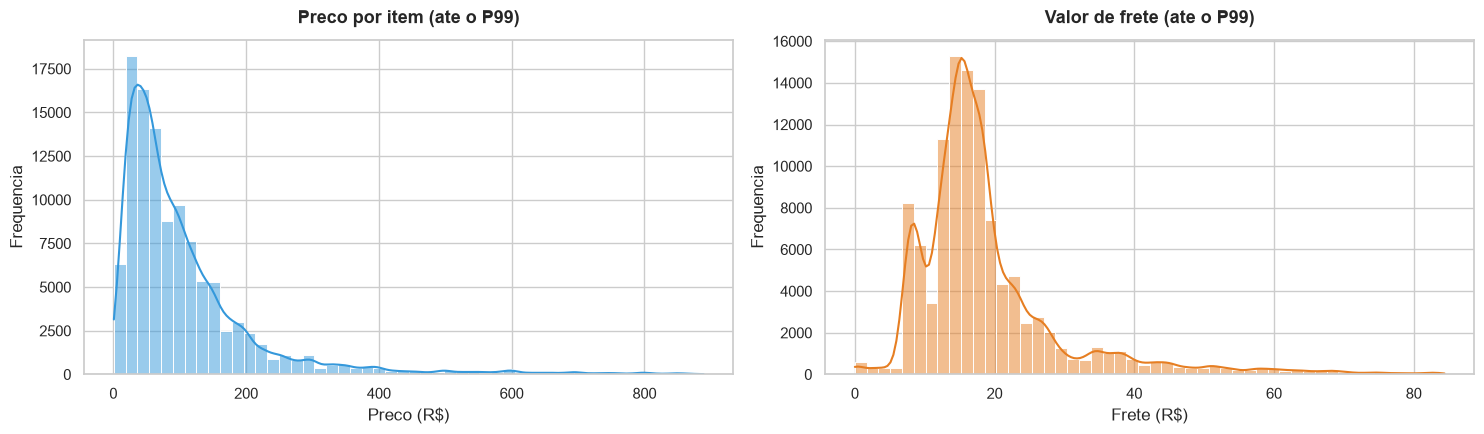

,faixa_de_valor,pedidos,frete_pct_do_valor
0,1. ate R$ 50,29522,56.90
1,2. R$ 50 a 150,44853,23.50
2,3. acima de R$ 150,23830,12.50


In [3]:
df_fin = conn.execute("SELECT price, freight_value, is_price_outlier FROM fato_itens").df()
display(df_fin[['price', 'freight_value']].describe())

print(f"Assimetria do preco:      {df_fin['price'].skew():.2f}")
print(f"Mediana vs media (preco): R$ {df_fin['price'].median():.2f} vs R$ {df_fin['price'].mean():.2f}")
print(f"Frete como % do GMV:      {100 * df_fin['freight_value'].sum() / df_fin['price'].sum():.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
# Corte no P99 apenas para leitura do grafico -- a cauda vai ate R$ 6.735.
sns.histplot(df_fin[df_fin['price'] < df_fin['price'].quantile(0.99)]['price'],
             bins=50, kde=True, ax=ax[0], color='#3498DB')
ax[0].set_title('Preco por item (ate o P99)', fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel('Preco (R$)')
ax[0].set_ylabel('Frequencia')

sns.histplot(df_fin[df_fin['freight_value'] < df_fin['freight_value'].quantile(0.99)]['freight_value'],
             bins=50, kde=True, ax=ax[1], color='#E67E22')
ax[1].set_title('Valor de frete (ate o P99)', fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel('Frete (R$)')
ax[1].set_ylabel('Frequencia')

plt.tight_layout()
plt.show()

# O frete pesa de forma muito desigual conforme o valor do pedido.
display(conn.execute("""
    SELECT CASE WHEN valor <= 50 THEN '1. ate R$ 50'
                WHEN valor <= 150 THEN '2. R$ 50 a 150'
                ELSE '3. acima de R$ 150' END AS faixa_de_valor,
           COUNT(*) AS pedidos,
           ROUND(AVG(100.0 * frete / valor), 1) AS frete_pct_do_valor
    FROM (SELECT order_id, SUM(price) AS valor, SUM(freight_value) AS frete
          FROM fato_itens GROUP BY 1)
    GROUP BY 1 ORDER BY 1
""").df())


## 3. Concentração geográfica

O desequilíbrio entre onde estão os compradores e onde estão os vendedores é a origem da fricção
logística explorada na Alavanca 3.


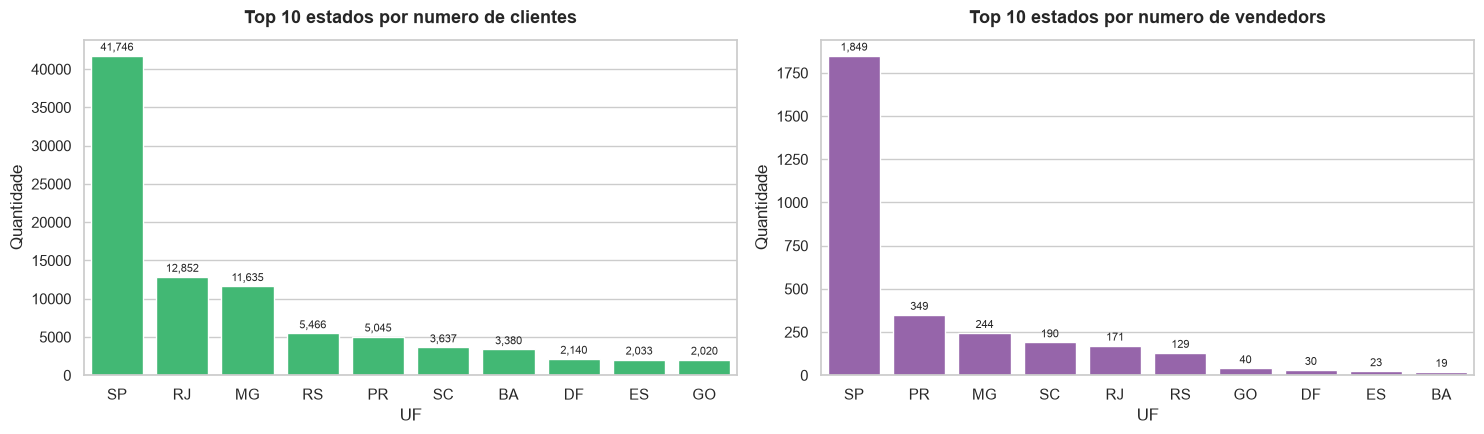

Sao Paulo concentra 1,849 de 3,095 vendedores (60%).


In [4]:
query_geo = """
SELECT 'Cliente' AS tipo, state, COUNT(*) AS qtd FROM dim_cliente GROUP BY 1, 2
UNION ALL
SELECT 'Vendedor', state, COUNT(*) FROM dim_vendedor GROUP BY 1, 2
"""
df_geo = conn.execute(query_geo).df()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for eixo, tipo, cor in [(0, 'Cliente', '#2ECC71'), (1, 'Vendedor', '#9B59B6')]:
    d = df_geo[df_geo['tipo'] == tipo].nlargest(10, 'qtd')
    sns.barplot(data=d, x='state', y='qtd', ax=ax[eixo], color=cor)
    ax[eixo].set_title(f'Top 10 estados por numero de {tipo.lower()}s',
                       fontsize=13, fontweight='bold', pad=12)
    ax[eixo].set_xlabel('UF')
    ax[eixo].set_ylabel('Quantidade')
    for p in ax[eixo].patches:
        ax[eixo].annotate(f'{int(p.get_height()):,}',
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                          textcoords='offset points')
plt.tight_layout()
plt.show()

sp = df_geo[(df_geo.tipo == 'Vendedor') & (df_geo.state == 'SP')]['qtd'].iloc[0]
tot = df_geo[df_geo.tipo == 'Vendedor']['qtd'].sum()
print(f"Sao Paulo concentra {sp:,} de {tot:,} vendedores ({sp / tot:.0%}).")


## 4. Meios de pagamento e avaliações

Composição das formas de pagamento — que sustenta a Alavanca 1 — e distribuição das notas, que
delimita a população de detratores tratada pelo módulo de NLP.


,payment_type,transacoes,valor,pct_valor
0,credit_card,76351,12444708.88,78.44
1,boleto,19689,2851857.17,17.98
2,voucher,5660,353771.95,2.23
3,debit_card,1522,215278.52,1.36


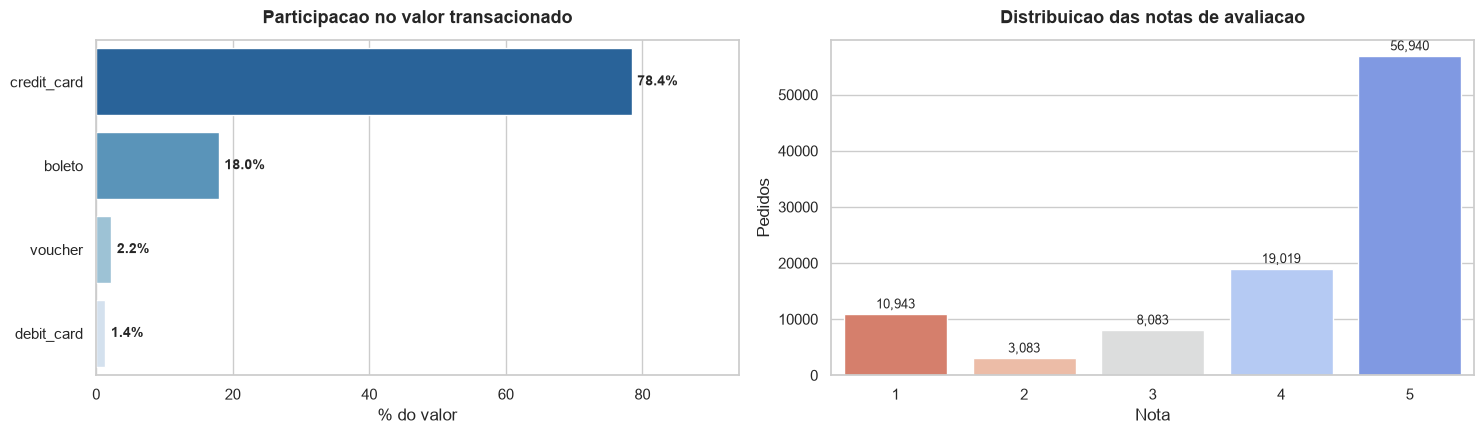

Detratores (nota <= 2): 14,026 de 98,068 pedidos avaliados (14.3%).
Essa e a populacao de entrada do pipeline de NLP.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

df_pay = conn.execute("""
    SELECT payment_type, COUNT(*) AS transacoes, ROUND(SUM(payment_value), 2) AS valor
    FROM fato_pagamentos GROUP BY 1 ORDER BY valor DESC
""").df()
df_pay['pct_valor'] = 100 * df_pay['valor'] / df_pay['valor'].sum()
display(df_pay)

sns.barplot(data=df_pay, x='pct_valor', y='payment_type', ax=ax[0], palette='Blues_r')
ax[0].set_title('Participacao no valor transacionado', fontsize=13, fontweight='bold', pad=12)
ax[0].set_xlabel('% do valor')
ax[0].set_ylabel('')
for p in ax[0].patches:
    ax[0].annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.8, p.get_y() + p.get_height() / 2),
                   ha='left', va='center', fontsize=10, fontweight='bold')
ax[0].set_xlim(0, df_pay['pct_valor'].max() * 1.2)

df_rev = conn.execute("""
    SELECT review_score, COUNT(*) AS pedidos FROM fato_pedidos
    WHERE review_score IS NOT NULL GROUP BY 1 ORDER BY 1
""").df()
sns.barplot(data=df_rev, x='review_score', y='pedidos', ax=ax[1], palette='coolwarm_r')
ax[1].set_title('Distribuicao das notas de avaliacao', fontsize=13, fontweight='bold', pad=12)
ax[1].set_xlabel('Nota')
ax[1].set_ylabel('Pedidos')
for p in ax[1].patches:
    ax[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

detratores = int(df_rev[df_rev.review_score <= 2]['pedidos'].sum())
avaliados = int(df_rev['pedidos'].sum())
print(f"Detratores (nota <= 2): {detratores:,} de {avaliados:,} pedidos avaliados ({detratores / avaliados:.1%}).")
print("Essa e a populacao de entrada do pipeline de NLP.")


In [6]:
conn.close()
print("Conexao encerrada.")


Conexao encerrada.
